# Customer Feedback Analysis and Automated Response

------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
warnings.filterwarnings("ignore")

In [2]:
!pip install python-dotenv

In [ ]:
from dotenv import load_dotenv
import os


True

## 1. Loading Data

In [5]:
load_dotenv()
PATH = os.getenv("FILE_PATH")
data = pd.read_csv(PATH)
data

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34655,AVpfiBlyLJeJML43-4Tp,NaN,B006GWO5WK,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",newamazonkindlefirehd9wpowerfastadaptercharger...,"Amazon Digital Services, Inc",2012-09-18T00:00:00Z,NaN,2015-08-29T00:00:00Z,...,NaN,NaN,NaN,3.0,http://www.amazon.com/Amazon-PowerFast-Adapter...,This is not appreciably faster than any other ...,Not appreciably faster than any other 1.8A cha...,NaN,NaN,Kris
34656,AVpfiBlyLJeJML43-4Tp,NaN,B006GWO5WK,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",newamazonkindlefirehd9wpowerfastadaptercharger...,"Amazon Digital Services, Inc",2012-11-21T00:00:00Z,NaN,2015-09-02T00:00:00Z,...,NaN,NaN,NaN,1.0,http://www.amazon.com/Amazon-PowerFast-Adapter...,Amazon should include this charger with the Ki...,Should be included,NaN,NaN,Jonathan Stewart
34657,AVpfiBlyLJeJML43-4Tp,NaN,B006GWO5WK,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",newamazonkindlefirehd9wpowerfastadaptercharger...,"Amazon Digital Services, Inc",2012-10-19T00:00:00Z,NaN,2015-09-04T00:00:00Z,...,NaN,NaN,NaN,1.0,http://www.amazon.com/Amazon-PowerFast-Adapter...,Love my Kindle Fire but I am really disappoint...,Disappointing Charger,NaN,NaN,J Lawson
34658,AVpfiBlyLJeJML43-4Tp,NaN,B006GWO5WK,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",newamazonkindlefirehd9wpowerfastadaptercharger...,"Amazon Digital Ser

## 2. Data Cleaning & Preprocessing

### Important Note: Here we will avoid removing rows from the data so that we dont miss out on some critical situations

In [ ]:
# Understanding Data
data.describe(include="all")

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
count,34660,27900,34658,34660,34660,34660,34660,34621,24039,34660,...,34066,1.0,34131.000000,34627.000000,34660,34659,34654,0.0,0.0,34653
unique,42,48,41,6,41,42,2,1078,1941,3911,...,2,NaN,NaN,NaN,11929,34659,19766,NaN,NaN,26788
top,AVphgVaX1cnluZ0-DR74,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",B018Y229OU,Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",firetablet7displaywifi8gbincludesspecialoffers...,Amazon,2017-01-16T00:00:00.000Z,2017-09-05T22:09:30Z,"2017-09-28T00:00:00Z,2017-09-08T00:00:00Z,2017...",...,True,NaN,NaN,NaN,https://www.amazon.com/product-reviews/B01J2G4...,This product so far has not disappointed. My c...,Great product,NaN,NaN,Mike
freq,10966,10966,10966,28701,10966,10966,34639,710,3127,5072,...,32682,NaN,NaN,NaN,387,1,645,NaN,NaN,138
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.630248,4.584573,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.215775,0.735653,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.dtypes

id                       object
name                     object
asins                    object
brand                    object
categories               object
keys                     object
manufacturer             object
reviews.date             object
reviews.dateAdded        object
reviews.dateSeen         object
reviews.didPurchase      object
reviews.doRecommend      object
reviews.id              float64
reviews.numHelpful      float64
reviews.rating          float64
reviews.sourceURLs       object
reviews.text             object
reviews.title            object
reviews.userCity        float64
reviews.userProvince    float64
reviews.username         object
dtype: object

In [ ]:
# Checking for nulls
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [ ]:
#Dropping columns with large no. of nulls and have low relevance
data.drop(['reviews.didPurchase','reviews.id','reviews.userCity','reviews.userProvince'],axis=1,inplace=True)
data.shape


(34660, 17)

In [ ]:
#Checking for duplicate data
data.duplicated().sum()

np.int64(0)

In [ ]:
# Remove doubles in names eg. Echo(White),,,Echo(White) -> Echo(White)
data['name']=data['name'].str.split(",,,").str[0]

# Remove Commas at the end
data['name']=data['name'].str.rstrip(",")
data['name']=data['name'].str.rstrip(" ")


In [ ]:
#Handling missing values in "name" column

data["name"].isna().sum()

np.int64(6760)

In [ ]:
# Custom filling null values with the help of "asins" and ("keys" or "reviews.sourceURLs") combination.

data.loc[(data['name'].isna()) & (data['asins'] == 'B00L9EPT8O,B01E6AO69U'), 'name'] = "Echo (White)"
data.loc[(data['name'].isna()) & (data['asins'] == 'B002Y27P6Y'), 'name'] = "Kindle Dx Leather Cover, Black (fits 9.7 Display, Latest and 2nd Generation Kindle Dxs)"
data.loc[(data['name'].isna()) & (data['asins'] == 'B006GWO5NE'), 'name'] = "Amazon Kindle Fire 5ft USB to Micro-USB Cable (works with most Micro-USB Tablets) "
data.loc[(data['name'].isna()) & (data['asins'] == 'B006GWO5WK'), 'name'] = "New Amazon Kindle Fire Hd 9w Powerfast Adapter Charger"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00BFJAHF8'), 'name'] = "Coconut Water Red Tea 16.5 Oz (pack of 12)"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00LW9XOJM'), 'name'] = "Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2014 Release), Cayenne Red"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00QFQRELG'), 'name'] = "New Amazon Kindle Fire Hd 9w Powerfast Adapter Charger"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00QL1ZN3G'), 'name'] = "Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00U3FPN4U'), 'name'] = "Amazon Fire Tv"
data.loc[(data['name'].isna()) & (data['asins'] == 'B00X4WHP5E'), 'name'] = "Echo (Black)"
data.loc[(data['name'].isna()) & (data['asins'] == 'B0189XYY0Q'), 'name'] = "Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum"
data.loc[(data['name'].isna()) & (data['asins'] == 'B018Y23P7K'), 'name'] = "Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta "
data.loc[(data['name'].isna()) & (data['asins'] == 'B01BH83OOM'), 'name'] = "Echo (Black)"



In [ ]:
# Creating New column to id the source of review
from urllib.parse import urlparse

data['source'] = data['reviews.sourceURLs'].apply(
    lambda x: urlparse(x.split(',')[0].strip()).netloc if pd.notna(x) else None
)
data['source'] = (
    data['source']
    .str.replace('www.', '', regex=False)
    .str.replace('.com', '', regex=False)
)


In [ ]:
# Dropping Columns on basis of domain knowledge / Correlation
data.drop(['keys','reviews.sourceURLs','asins'],axis=1,inplace=True)


In [ ]:
# fill missing ratings on basis of keywords in reviews (and keeping the rating form 2-4 so we do not generate bias data)
good_keywords=["excellent", "flawless", "superb", "outstanding", "impressive", "reliable", "worth every penny", "exceeded my expectations", "highly recommend", "will buy again","holding up perfectly", "use it every day", "built to last", "plug and play", "effortless setup", "user-friendly"]
bad_keywords=["fell apart", "stopped working", "cheaply made", "defective", "flimsy", "shoddy","overheats", "lags constantly", "inaccurate", "loud noise","nightmare", "garbage", "trash", "waste of money", "contacted customer service", "highly disappointed", "return policy", "sending it back","worst","broken","late","rude"]

good_pattern = '|'.join(good_keywords)
bad_pattern = '|'.join(bad_keywords)

review_text = (
    data['reviews.title'].fillna('') + " " +
    data['reviews.text'].fillna('')
)

missing_rating = data['reviews.rating'].isna()

data.loc[
    missing_rating & review_text.str.contains(good_pattern, case=False, regex=True),
    'reviews.rating'
] = 4


data.loc[
    missing_rating & review_text.str.contains(bad_pattern, case=False, regex=True),
    'reviews.rating'
] = 2


# Remaining missing ratings
data['reviews.rating'] = data['reviews.rating'].fillna(3)

In [ ]:
# Date formatting
data['reviews.date'] = pd.to_datetime(data['reviews.date'], errors='coerce').dt.date
data['reviews.dateAdded'] = pd.to_datetime(data['reviews.dateAdded'], errors='coerce').dt.date
data['reviews.dateSeen'] = pd.to_datetime(
    data['reviews.dateSeen'].str.split(',').str[-1],
    format='mixed',
    utc=True,
    errors='coerce'
).dt.date


## 3. EDA

### KPI

In [ ]:
from IPython.display import display, HTML




totalReviews= data['id'].count()
avgRatings= data['reviews.rating'].mean()
recRate = (
    (data['reviews.doRecommend'] == True).sum()
    / data['reviews.doRecommend'].notna().sum()
) * 100



kpi_html = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; display: flex; flex-direction: column; gap: 15px; margin: 15px 0; width: 100%;">
    
    <!-- ROW 1: 3 CARDS SIDE-BY-SIDE -->
    <div style="display: flex; gap: 15px; width: 100%;">
        
        <!-- Card 1 -->
        <div style="flex: 1; width: 31%; padding: 15px; background-color: #f8f9fa; border-left: 5px solid #0d6efd; border-radius: 6px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <div style="font-size: 11px; color: #6c757d; font-weight: 600; text-transform: uppercase; letter-spacing: 0.5px;">Total Reviews</div>
            <div style="font-size: 24px; color: #212529; font-weight: 700; margin-top: 5px;">{totalReviews:,}</div>
        </div>

        <!-- Card 2 -->
        <div style="flex: 1; width: 31%; padding: 15px; background-color: #f8f9fa; border-left: 5px solid  #fd7e14; border-radius: 6px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <div style="font-size: 11px; color: #6c757d; font-weight: 600; text-transform: uppercase; letter-spacing: 0.5px;">Avg Ratings</div>
            <div style="font-size: 24px; color: #212529; font-weight: 700; margin-top: 5px;">{avgRatings:,.2f} star</div>           
        </div>

        <!-- Card 3 -->
        <div style="flex: 1; width: 31%; padding: 15px; background-color: #f8f9fa; border-left: 5px solid #6f42c1; border-radius: 6px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <div style="font-size: 11px; color: #6c757d; font-weight: 600; text-transform: uppercase; letter-spacing: 0.5px;">Recommendation Rate</div>
            <div style="font-size: 24px; color: #212529; font-weight: 700; margin-top: 5px;">{recRate:.2f}%</div>
        </div>

    </div>



    </div>

</div>
"""

# --- 3. Render Dashboard ---
display(HTML(kpi_html))

### Product Analysis

Top 10 highest rated Products

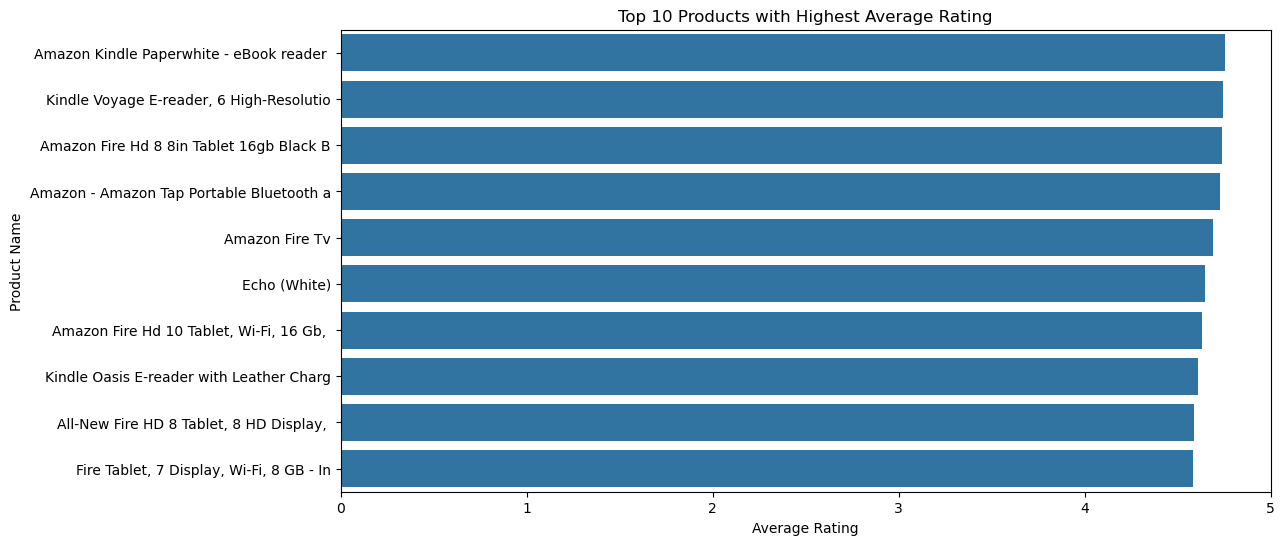

In [ ]:
product_rating = (
    data.groupby('name')
    .agg(
        avg_rating=('reviews.rating','mean'),
        review_count=('reviews.rating','count')
    )
)

# Keep products with at least 50 reviews
top_rating_products = (
    product_rating[product_rating['review_count'] >= 50]
    .sort_values('avg_rating', ascending=False)
    .head(10)
)

top_rating_products['short_name'] = top_rating_products.index.str[:40]

plt.figure(figsize=(12,6))

sns.barplot(
    x='avg_rating',
    y='short_name',
    data=top_rating_products
)

plt.xlabel("Average Rating")
plt.ylabel("Product Name")
plt.title("Top 10 Products with Highest Average Rating")

plt.xlim(0,5)
plt.show()



## Insights 

- There's no strong correlation between review volume and average rating — e.g., "Fire Tablet, 7 Display, 8GB" has ~10,966 reviews but a middling 4.45 average, while niche products with far fewer reviews (e.g., Fire HD 8, 2814 reviews) score similarly or higher.
- The lowest-rated product in this list is the Kindle Fire HD 9w Charger (3.94) — accessories/chargers tend to underperform relative to core devices, hinting at quality-control or compatibility complaints.
- Core Fire tablets and the Echo consistently land in the 4.4–4.6 range, indicating solid overall customer satisfaction for flagship products.

Lowest Rated products

In [ ]:
# Lowest Rated Products
lowest_rating_products = (
    product_rating[product_rating['review_count'] >= 50]
    .sort_values('avg_rating', ascending=True)
    .head(10)
)

lowest_rating_products[['avg_rating','review_count']]

,avg_rating,review_count
name,,
New Amazon Kindle Fire Hd 9w Powerfast Adapter Charger,3.941860,86
Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,4.367713,223
"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",4.429245,212
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",4.452581,10966
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",4.462025,158
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",4.510386,1685
Echo (Black),4.531685,647
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,4.545279,1038
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.580645,372


### Rating Analysis

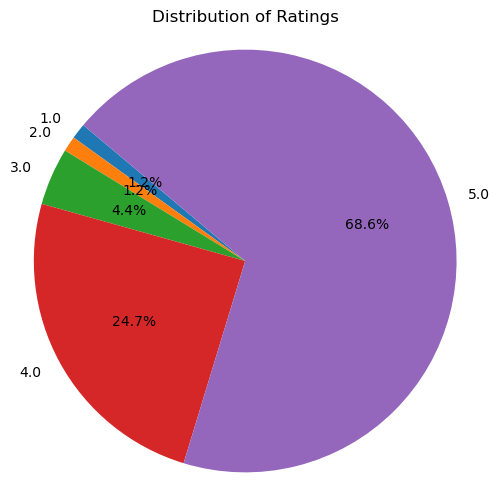

In [ ]:
rating_counts = data['reviews.rating'].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Distribution of Ratings')
plt.axis('equal')

plt.show()

## Insights
- The dataset is heavily skewed positive: 68.6% are 5-star and 24.7% are 4-star — nearly 93% of all reviews are positive (4-5 stars).
- Only 1.2% are 1-star and 1.2% are 2-star, meaning negative feedback is rare but (per Image 5) disproportionately impactful/helpful when it appears.
- This heavy positive skew is typical of e-commerce review data and suggests potential self-selection bias (satisfied customers review more often, or unhappy customers return products instead of reviewing).

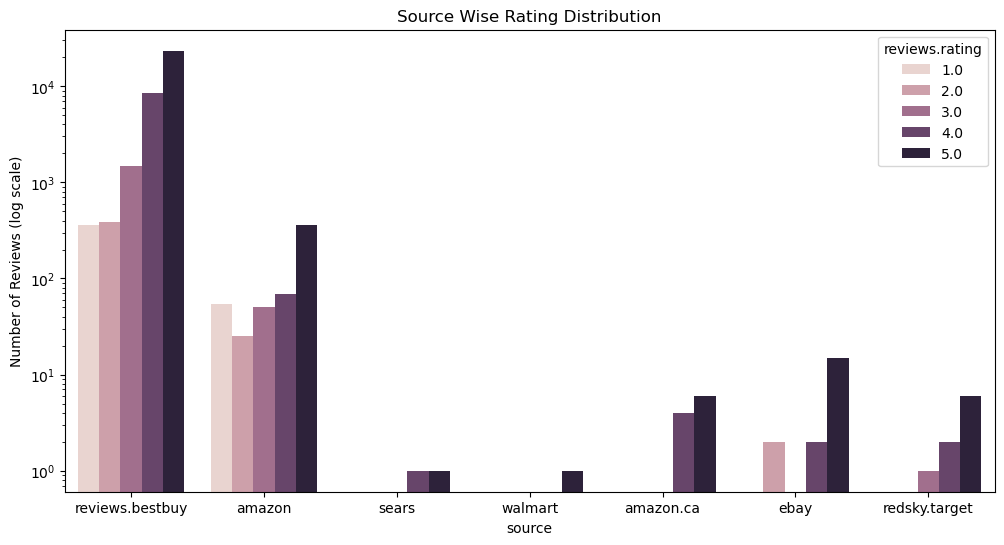

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x="source", hue="reviews.rating", data=data)
plt.yscale('log')
plt.ylabel("Number of Reviews (log scale)")
plt.title("Source Wise Rating Distribution")
plt.show()

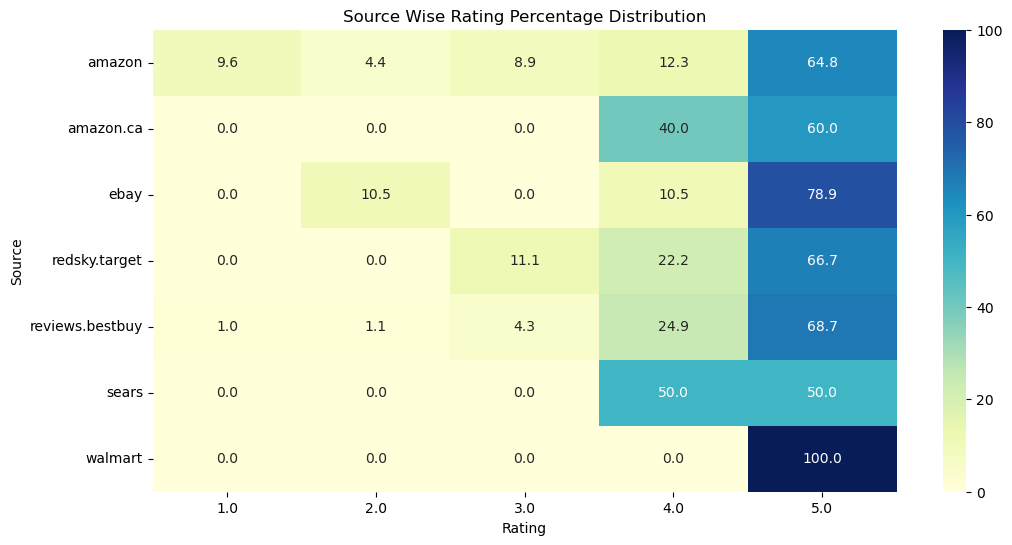

In [ ]:
rating_heatmap = data.pivot_table(
    index="source",
    columns="reviews.rating",
    values="id",
    aggfunc="count",
    fill_value=0
)

rating_percent = rating_heatmap.div(
    rating_heatmap.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(12,6))

sns.heatmap(
    rating_percent,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.xlabel("Rating")
plt.ylabel("Source")
plt.title("Source Wise Rating Percentage Distribution")
plt.show()

## Insights
- Walmart shows a suspicious 100% 5-star distribution — likely a very small sample size rather than genuinely perfect satisfaction (should be validated against review counts).
- Amazon (the largest source) has the most "realistic" and diverse distribution, with meaningful shares across 1–5 stars (9.6% 1-star, 64.8% 5-star), reflecting a large, organic sample.
- eBay has a notably high 2-star proportion (10.5%) with zero 1 or 3-star reviews — an unusual pattern that could reflect a small/biased sample or platform-specific customer behavior.

### Helpful Votes Analysis

Top 10 most helpful reviews

In [ ]:
data.sort_values(by='reviews.numHelpful', ascending=False)[
    ['name', 'reviews.rating', 'reviews.text', 'reviews.numHelpful']
].head(10)

,name,reviews.rating,reviews.text,reviews.numHelpful
28947,Echo (Black),5.0,IMPORTANT UPDATE (3/8/17): As you read my orig...,814.0
21219,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5.0,"Since the Fire TV stick was announced, I've he...",780.0
34627,Amazon Fire Tv,4.0,"Hey Alexa, Hey Alexa - Night and day it's Hey ...",744.0
21220,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5.0,UPDATE! 11/11/15: More than a year now of usin...,740.0
2882,Amazon Kindle Lighted Leather Cover,3.0,"I owned a Kindle Keyboard for about a year, an...",730.0
34625,Amazon Fire Tv,5.0,This review is more of a guide for cablecutter...,660.0
21218,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5.0,I was fortunate to order one of these as soon ...,650.0
28668,Amazon 5W USB Official OEM Charger and Power A...,4.0,"These days, Amazon doesn't supply a charger wh...",629.0
29380,Echo (Black),5.0,It was just a few weeks ago that I was bemoani...,434.0
28670,Amazon 5W USB Official OEM Charger and Power A...,1.0,This is clearly taking advantaged of Kindle cu...,422.0


## Insights

- The most "helpful" reviews are dominated by Echo, Fire Tablet, and Fire TV products — signaling these are the most talked-about/controversial items in the dataset.

- Interestingly, a 1-star review (Amazon 5W Charger) also cracked the top 10 most-helpful list, showing that critical reviews can be just as valuable to buyers as glowing ones.

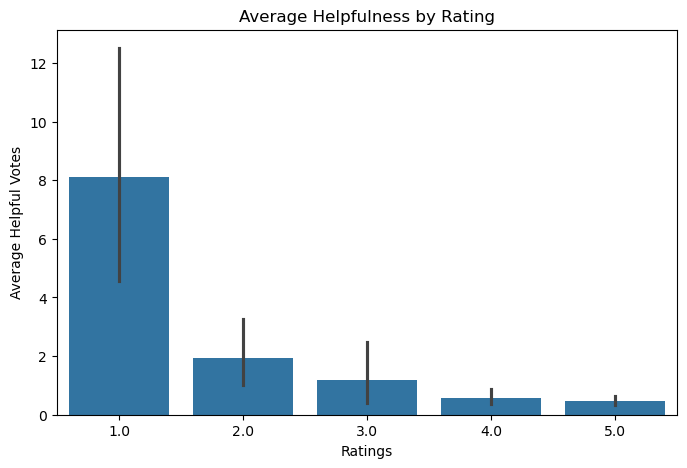

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=data,
    x='reviews.rating',
    y='reviews.numHelpful',
    estimator='mean'
)

plt.title("Average Helpfulness by Rating")
plt.xlabel("Ratings")
plt.ylabel("Average Helpful Votes")
plt.show()

## Insights
- There's a strong inverse relationship between star rating and helpfulness: 1-star reviews receive by far the most "helpful" votes (~8 on average), while 5-star reviews receive the least (~0.5).
- This suggests shoppers rely much more heavily on negative reviews to make purchase decisions — critical reviews carry outsized influence despite being a minority of the dataset.
- The very large error bar (confidence interval) on the 1-star category indicates high variance — a few extremely popular negative reviews may be skewing the average.

Focus Products (low avg rating with max helpful votes)

In [ ]:

product_analysis = data.groupby('name').agg(
    avg_rating=('reviews.rating', 'mean'),
    max_helpful_votes=('reviews.numHelpful', 'max'),
    total_reviews=('reviews.rating', 'count')
)

product_analysis[
    (product_analysis['avg_rating'] <= 3)
].sort_values(
    'max_helpful_votes',
    ascending=False
).head(10)


,avg_rating,max_helpful_votes,total_reviews
name,,,
Kindle Keyboard,2.888889,221.0,9


## Insights
- The product showing low rating and people backing the ratings show there is some problem in the product.

## Time Analysis

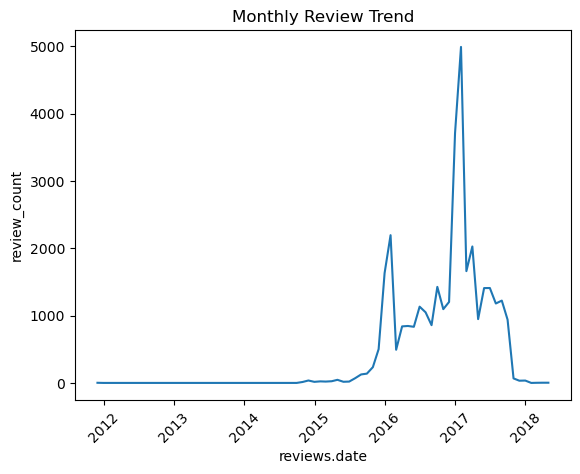

In [ ]:
data['reviews.date'] = pd.to_datetime(data['reviews.date'])

monthly_reviews = (
    data
    .set_index('reviews.date')
    .resample('M')
    .size()
    .reset_index(name='review_count')
)

sns.lineplot(
    data=monthly_reviews,
    x='reviews.date',
    y='review_count'
)

plt.xticks(rotation=45)
plt.title("Monthly Review Trend")
plt.show()

### Negative Reviews Analysis

In [ ]:
negative_reviews = data.loc[data["reviews.rating"] < 3]
negative_reviews


,id,name,brand,categories,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.text,reviews.title,reviews.username,source
117,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-08,2017-05-21,2017-06-07,True,0.0,2.0,Didn't have some of the features I was looking...,Wasn't for me,Mark,reviews.bestbuy
126,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-10,2017-05-21,2017-06-07,False,2.0,1.0,i Bought this around black friday for $60 hopi...,TERRIBLE DONT BUY,Brandon,reviews.bestbuy
169,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2016-11-25,2017-05-21,2017-06-07,False,2.0,1.0,I bought this tablet for my 4 year old daughte...,Ended up returning,Mijenx,reviews.bestbuy
241,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-30,2017-05-21,2017-06-07,False,0.0,1.0,Didn't want to go to the sites amazon wanted m...,returned item,turtle,reviews.bestbuy
281,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-04-18,2017-05-21,2017-06-07,False,0.0,2.0,Not a good product short battery life i can on...,short life,notonfire1,reviews.bestbuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34654,AVpfiBlyLJeJML43-4Tp,New Amazon Kindle Fire Hd 9w Powerfast Adapter...,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...","Amazon Digital Services, Inc",NaT,NaT,2015-08-13,NaN,NaN,1.0,This is exactly like any other usb power charg...,Not Necessary,mir_,amazon
34656,AVpfiBlyLJeJML43-4Tp,New Amazon Kindle Fire Hd 9w Powerfast Adapter...,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...","Amazon Digital Services, Inc",NaT,NaT,2015-09-02,NaN,NaN,1.0,Amazon should include this charger with the Ki...,Should be included,Jonathan Stewart,amazon
34657,AVpfiBlyLJeJML43-4Tp,New Amazon Kindle Fire Hd 9w Powerfast Adapter...,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...","Amazon Digital Services, Inc",NaT,NaT,2015-09-04,NaN,NaN,1.0,Love my Kindle Fire but I am really disappoint...,Disappointing Charger,J Lawson,amazon
34658,AVpfiBlyLJeJML43-4Tp,New Amazon Kindle Fire Hd 9w Powerfast Adapter...,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...","Amazon Digital Services, Inc",NaT,NaT,2015-09-01,NaN,NaN,1.0,I was surprised to find it did not come with a...,Not worth the money,Just the Buyer,amazon


In [ ]:
from collections import Counter

from collections import Counter
import re


target_words = ["fell apart", "stopped working", "cheaply made", "defective", "flimsy", "shoddy","overheats", "lags constantly", 
                "inaccurate", "loud noise","nightmare", "garbage", "trash", "waste of money", "contacted customer service", 
                "highly disappointed", "return policy",
                "sending it back","worst","broken","late","rude"]

# Combine both columns
text = (
    negative_reviews['reviews.title'].fillna('') + ' ' +
    negative_reviews['reviews.text'].fillna('')
).str.lower()


all_words = re.findall(r'\b\w+\b', ' '.join(text))

# Count all words
counter = Counter(all_words)

# Get counts for your specific words
word_counts = {word: counter[word] for word in target_words}

#df
count_df = pd.DataFrame(
    word_counts.items(),
    columns=['Word', 'Count']
).sort_values('Count', ascending=False).reset_index(drop=True)

print(count_df)


                          Word  Count
0                    defective     21
1                        worst     16
2                       broken      8
3                      garbage      5
4                         late      4
5                       flimsy      2
6                    overheats      1
7                   inaccurate      1
8                        trash      1
9   contacted customer service      0
10             sending it back      0
11               return policy      0
12         highly disappointed      0
13                  fell apart      0
14              waste of money      0
15             stopped working      0
16                   nightmare      0
17                  loud noise      0
18             lags constantly      0
19                      shoddy      0
20                cheaply made      0
21                        rude      0


In [ ]:
import plotly.express as px

fig = px.treemap(
    count_df,
    path=['Word'],
    values='Count',
    title='Word Frequency'
)

fig.update_traces(
    texttemplate="<b>%{label}</b><br>Count: %{value}",
    textfont_size=16
)


fig.show()

## Insights

1. Product quality failure dominates the complaints. "Defective" (21) and "worst" (16) alone make up ~65% of all negative-review keywords — far outweighing every other term combined — showing dissatisfaction is concentrated on fundamental quality issues, not price or service.
2. Complaints center on physical/functional breakdown, not usability. The vocabulary (defective, broken, garbage, flimsy, overheats, inaccurate) points to hardware failure and defects as the core driver of negative sentiment, rather than confusion or subjective disappointment.
3. Delivery is a secondary, distinct issue. "Late" (4) is the only major non-quality complaint, signaling a separate fulfillment/logistics problem worth addressing independently from product QA.


## Automation

In [ ]:
# Selecting top 3 critical reviews


rating_weight = {
    1: 5,
    2: 4
}

# for first filter layer
# Priority = Helpful Votes × Rating Weight × Review Length

negative_reviews['priority_score'] = (
    negative_reviews['reviews.numHelpful'].fillna(0) *
    negative_reviews['reviews.rating'].map(rating_weight) *
    negative_reviews['reviews.text'].str.len().fillna(0)
)


top10 = negative_reviews.sort_values(
    'priority_score',
    ascending=False
)[[
    'name',
    'reviews.rating',
    'reviews.numHelpful',
    'reviews.title',
    'reviews.text',
    'reviews.username',
    'priority_score'
]].head(10)



# Second filter layer
# Extracting top 3
critical_words = [
    'broken', 'refund', 'return', 'defective',
    'fire', 'danger', 'cracked', 'doesnt work',
    'stopped working', 'replacement'
]

pattern = '|'.join(critical_words)

# Combine title and review text
top10['combined_text'] = (
    top10['reviews.title'].fillna('') + ' ' +
    top10['reviews.text'].fillna('')
).str.lower()

critical3 = top10[
    top10['combined_text'].str.contains(pattern, na=False)
]

critical3.sort_values(
    by='reviews.numHelpful',
    ascending=False
)[[
    'name',
    'reviews.rating',
    'reviews.numHelpful',
    'reviews.title',
    'reviews.text',
    'reviews.username',
    'priority_score'
    
]].head(3)



,name,reviews.rating,reviews.numHelpful,reviews.title,reviews.text,reviews.username,priority_score
21562,Echo (White),1.0,292.0,"Purchase a new one, stay away from the refurbi...",Stay away from the certified refurbished Amazo...,Amazon Customer,889140.0
34387,Amazon Fire Tv,2.0,69.0,Almost...,It's somewhat of a step up from the Roku 3 I w...,benjitek,475272.0
34384,Amazon Fire Tv,2.0,49.0,For dedicated Amazon Prime users only,Pros:- Amazon Prime works on it.- You can stil...,tvans,265188.0


In [ ]:
!pip install -U google-genai

In [6]:
# connecting to client
from google import genai

gemini_key = os.getenv("GEMINI_API_KEY")

client = genai.Client(api_key=gemini_key)

In [ ]:
emails = []

for _, row in critical3.iterrows():

    prompt = f"""
You are an experienced Customer Support Agent for Amazon.

Your task is to write a personalized apology email for the customer.

Requirements:
- Address the customer by saying "Dear Customer,"
- Acknowledge the specific issues mentioned.
- Apologize sincerely.
- Explain that the issue is important to the company.
- Offer an appropriate resolution (refund, replacement, troubleshooting, or support).
- End politely.
- Keep the email between 120 and 180 words.
- Do not invent details that are not mentioned in the review.

Review Title:
{row['reviews.title']}

Review:
{row['reviews.text']}
"""

    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=prompt
    )

    emails.append(response.text)

In [ ]:
emails

['Dear Customer,\n\nI am writing to you today to sincerely apologize for your frustrating experience with the Certified Refurbished Amazon Fire TVs you received. It is truly disappointing to hear that your first unit arrived with a corrupted screen and your second unit failed to boot, remaining stuck in an infinite loop.\n\nPlease know that we take your feedback regarding our refurbishment process and quality control very seriously. Maintaining high standards is incredibly important to us, and I have shared your specific concerns with our quality assurance team to ensure we improve these services moving forward.\n\nWhile I am glad to hear that your new Fire TV is working perfectly, I would like to make this right regarding the defective units. I have processed a full refund for both refurbished orders as a gesture of goodwill. You do not need to take any further action. Thank you for your patience and for bringing this to our attention. We truly value your business.\n\nBest regards,\n\

# Pregenerated Emails:

## Email 1

**Subject:** Apology Regarding Your Certified Refurbished Amazon Fire TV Experience

Dear Customer,

I am writing to you today to sincerely apologize for your frustrating experience with the Certified Refurbished Amazon Fire TVs you received. It is truly disappointing to hear that your first unit arrived with a corrupted screen and your second unit failed to boot, remaining stuck in an infinite loop.

Please know that we take your feedback regarding our refurbishment process and quality control very seriously. Maintaining high standards is incredibly important to us, and I have shared your specific concerns with our quality assurance team to ensure we improve these services moving forward.

While I am glad to hear that your new Fire TV is working perfectly, I would like to make this right regarding the defective units. I have processed a full refund for both refurbished orders as a gesture of goodwill. You do not need to take any further action.

Thank you for your patience and for bringing this to our attention. We truly value your business.

Best regards,  
Amazon Customer Support


---

## Email 2

**Subject:** Support Regarding Your Fire TV Connectivity and User Experience Issues

Dear Customer,

Thank you for reaching out to us regarding your recent experience with the Fire TV. I sincerely apologize for the frustration you encountered while setting up your 5GHz network connection and for the ongoing issues regarding Bluetooth audio synchronization and the navigation interface.

We truly value your feedback, as it is essential in helping us improve our products and services. Providing a seamless entertainment experience is very important to us, and I regret that we fell short of your expectations.

I have documented your concerns regarding the UI customization and universal search limitations to share with our development team for future updates.

To address your disappointment, I would like to offer you a partial refund as a gesture of goodwill for the time you spent troubleshooting. Additionally, if you decide the device is not the right fit for your needs, I am happy to assist you with a prepaid return label for a full refund.

Thank you for your patience and for choosing Amazon.

Best regards,  
Customer Support Team


---

## Email 3

**Subject:** Resolution Regarding Your Fire TV Performance Concerns

Dear Customer,

Thank you for sharing your detailed feedback regarding your experience with the latest Fire TV.

I am sincerely sorry to hear that the device has failed to meet your expectations, particularly concerning the unresponsive remote, persistent connectivity issues, and the overall lack of system optimization you described.

At Amazon, we strive to provide high-quality, seamless technology, and your concerns regarding the interface performance and hardware limitations are incredibly important to us.

Since you are not satisfied with your purchase, I would like to offer you a full refund for the device. Please initiate the return process through your "Your Orders" page, and we will ensure the funds are returned to your original payment method promptly.

If you require any assistance with the return label or have further questions, please reach out to us directly.

We apologize for this disappointment and appreciate your patience.

Best regards,  
Customer Support Team  
Amazon